In [1]:
# =====================================================================
# Part I - Finance - TEMPLATE
# =====================================================================
# The framework (finance_toolkit) fixes two things for everyone: how
# the data is loaded, and how a score panel is scored into a PnL,
# Sharpe and turnover.  Everything in the middle is yours.
#
# THE FLOW:
#   1. data is loaded for you (same for the whole class),
#   2. YOU build a SUPERSET of named features (FREE 1),
#   3. YOU write ONE recipe build_alpha(config) (FREE 2): a config
#      (feature subset, model, hyperparams) -> a trained model ->
#      scores -> positions -> its daily PnL,
#   4. YOU loop that recipe over MANY configs (FREE 3) to make many alphas,
#   5. the framework evaluates every alpha (Sharpe, turnover, ...),
#      shows the correlation between them, and keeps the best
#      un-correlated set.
#
# Your model only has to satisfy the MODEL CONTRACT:
#
#     model.predict(feat_t) -> scores
#     feat_t : float tensor (days, stocks, features)
#     scores : float tensor (days, stocks)
#
# Everything is a "panel": a table of shape (days x stocks).  Every
# operator takes panels and returns a panel of the same shape.

In [2]:
import os
import json
import numpy
import torch
import finance_toolkit as toolkit

# =====================================================================
# FIXED 1
# =====================================================================
SEED = 42
torch.manual_seed(SEED)
numpy.random.seed(SEED)
torch.set_num_threads(4)

# Everything up to SPLIT_DATE trains; the rest is a local hold-out
# you score yourself.  The instructor's HIDDEN slice is a separate,
# even later date range you never see.

DATA_DIR = "../data"
panels = toolkit.load_prices(DATA_DIR)

# This will be used for the target of the model.
forward_returns = toolkit.forward_return(panels["returns"])
mask = toolkit.valid_mask(panels, min_history=60)

all_dates = panels["close"].index
tickers = panels["close"].columns
print("panel:", panels["close"].shape, "dates",
      all_dates.min().date(), "to", all_dates.max().date())

# you may choose another split.
SPLIT_DATE = "2020-01-01"
is_train = all_dates < SPLIT_DATE
is_test = ~is_train
print("train days:", int(is_train.sum()),
      " test days:", int(is_test.sum()))


close = panels["close"]
open_ = panels["open"]
high = panels["high"]
low = panels["low"]
volume = panels["volume"]
returns = panels["returns"]
sector, industry = toolkit.load_groups("../data/groups.csv")

panel: (2669, 2994) dates 2013-01-02 to 2023-06-30
train days: 1775  test days: 894


In [3]:
# =====================================================================
# >>> FREE 1 <<<   your features
# =====================================================================
# 12 features across five families. Every one is now sector- (or, for
# the two originally industry-neutral reversal features, industry-)
# neutralized, per the assignment's tip: "Neutralise by sector to drop
# sector bets." Round-1 through round-3 only neutralized 3 of the
# original 13; the round-1 correlation diagnostic showed the biggest
# blocker in the whole search was mlp_all_b_s2 (blocked 15 of 27
# excluded-but-qualifying alphas, correlation up to 0.99 with its own
# near-duplicate) -- consistent with un-neutralized features sharing a
# common sector/market tilt that shows up as correlated PnL regardless
# of which specific feature combination a model uses.
#
# Sector-neutralizing mom_20 makes it mathematically identical to the
# old separately-named "sector_mom_20" (both were the same 20-day
# mean-return signal, one market-wide, one sector-neutral -- neutralize
# the first and they collapse into one), so that name is retired
# rather than kept as a duplicate: 13 features become 12.
#
#   momentum   -- mean return over 5/20/60 days, sector-neutral
#                 (mom_5, mom_20, mom_60)
#   reversal   -- yesterday's return negated, the worked intraday
#                 example, both sector-neutral; 5-day reversal within
#                 industry (finer-grained, already neutral)
#                 (rev_1, intraday_rev_20, industry_rev_5)
#   technical  -- position within the day's high/low range, the
#                 overnight open-vs-prior-close gap, deviation from
#                 the 20-day moving average -- all sector-neutral
#                 (range_pos, gap, price_to_ma20)
#   volatility -- 20-day realized vol, 20-day average relative
#                 high-low range -- sector-neutral
#                 (vol_20, high_low_range_20)
#   volume     -- today's volume z-scored against its own 20-day
#                 history, then sector-neutralized (volume_spike_20)
all_features = {
    "mom_5": toolkit.cs_zscore(toolkit.ts_mean(returns, 5), sector),
    "mom_20": toolkit.cs_zscore(toolkit.ts_mean(returns, 20), sector),
    "mom_60": toolkit.cs_zscore(toolkit.ts_mean(returns, 60), sector),
    "rev_1": toolkit.cs_zscore(-returns, sector),
    "intraday_rev_20": toolkit.cs_zscore(toolkit.ts_zscore(open_ - close, 20), sector),
    "industry_rev_5": toolkit.cs_zscore(-toolkit.ts_mean(returns, 5), industry),
    "range_pos": toolkit.cs_zscore((close - low) / (high - low), sector),
    "gap": toolkit.cs_zscore((open_ - close.shift(1)) / close.shift(1), sector),
    "price_to_ma20": toolkit.cs_zscore((close - toolkit.ts_mean(close, 20)) / toolkit.ts_mean(close, 20), sector),
    "vol_20": toolkit.cs_zscore(toolkit.ts_std(returns, 20), sector),
    "high_low_range_20": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), sector),
    "volume_spike_20": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), sector),

    # Round 5 additions: the 12 features above gave only 6 mutually
    # uncorrelated alphas across 22 configs -- most alphas, whatever
    # feature or model built them, converged onto a handful of shared
    # factors. What actually decorrelated was the volume/volatility/
    # range-positioning family, so this doubles down on it with new
    # constructions (not just new windows): a windowed range position,
    # a volume trend, a volatility regime change, and industry- (rather
    # than sector-) neutral variants of the two best performers.
    "range_pos_5": toolkit.cs_zscore(toolkit.ts_mean((close - low) / (high - low), 5), sector),
    "volume_trend": toolkit.cs_zscore(toolkit.ts_mean(volume, 5) - toolkit.ts_mean(volume, 20), sector),
    "vol_change": toolkit.cs_zscore(toolkit.ts_std(returns, 20) - toolkit.ts_std(returns, 60), sector),
    "vol_20_industry": toolkit.cs_zscore(toolkit.ts_std(returns, 20), industry),
    "volume_spike_20_industry": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), industry),
    "hlrange_industry": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), industry),
}

all_feature_panel = toolkit.build_features(all_features, panels)
# float32 instead of pandas' default float64: halves the memory of
# every downstream stack/tensor built from these panels. This machine
# has 8GB RAM shared with other running apps, and stacking many
# features at float64 reliably fails with an out-of-memory error here
# (measured: a single ~800MB allocation at 13 features). The final
# model tensors are float32 regardless -- make_tensors casts
# explicitly -- so this only removes a redundant doubling, it never
# changes any result.
all_feature_panel = {k: v.astype("float32") for k, v in all_feature_panel.items()}
all_feature_names = sorted(all_feature_panel)
print("features available:", all_feature_names)

# Feature-family subsets: each is one hypothesis about what drives the
# 2-day-ahead return, so alphas built from different subsets start out
# making genuinely different bets (see FREE 3 for why this mattered).
momentum_set = ["mom_5", "mom_20", "mom_60"]
reversal_set = ["rev_1", "intraday_rev_20", "industry_rev_5"]
vol_volume_set = ["vol_20", "high_low_range_20", "volume_spike_20"]
technical_set = ["range_pos", "gap", "price_to_ma20"]
mixed_set = ["mom_20", "rev_1", "range_pos", "vol_20", "gap"]
all_set = all_feature_names

features available: ['gap', 'high_low_range_20', 'hlrange_industry', 'industry_rev_5', 'intraday_rev_20', 'mom_20', 'mom_5', 'mom_60', 'price_to_ma20', 'range_pos', 'range_pos_5', 'rev_1', 'vol_20', 'vol_20_industry', 'vol_change', 'volume_spike_20', 'volume_spike_20_industry', 'volume_trend']


In [4]:
# =====================================================================
# >>> FREE 2 <<<   one recipe for building an alpha
# =====================================================================
# Two small subclasses first, then the recipe.
#
# Why subclass instead of using toolkit.MLP / toolkit.LSTM directly:
# finance_toolkit.predict_scores runs model.predict(feat_t) on the
# FULL (days, stocks, features) tensor in one shot -- no batching.
# For the LSTM that means one un-batched forward pass over ~2700 days
# x ~3000 stocks, which needs a single ~8GB allocation and reliably
# crashes on this 8GB machine (measured directly while developing
# this). predict_scores is part of the FIXED framework, so it can't
# be changed; instead these subclasses override only predict() to
# process the day axis in chunks (carrying LSTM hidden state across
# chunks), giving the exact same output with a small, bounded memory
# footprint. MLP.step() also calls self.predict() during training, so
# SafeMLP must NOT force no_grad in predict() or gradients break.


class SafeMLP(toolkit.MLP):
    def predict(self, x, chunk_days=300):
        outs = [toolkit.MLP.predict(self, x[start:start + chunk_days])
                for start in range(0, x.shape[0], chunk_days)]
        return torch.cat(outs, dim=0)


class SafeLSTM(toolkit.LSTM):
    def predict(self, x, chunk_days=150):
        outs, state = [], None
        with torch.no_grad():
            for start in range(0, x.shape[0], chunk_days):
                out, state = self.step(x[start:start + chunk_days], state)
                outs.append(out)
        return torch.cat(outs, dim=0)


# Round 5 additions: two genuinely different inductive biases from
# MLP/LSTM, added after a correlation diagnostic showed MLP and LSTM
# alphas across different feature families still converge on shared
# factors. Neither has any cross-feature interaction (LinearAlpha) or
# any memory across days (both) -- structurally distinct enough that
# they turned out to decorrelate far better than more MLP/LSTM variants.
class LinearAlpha(torch.nn.Module):
    """score = w . features + b -- no hidden layers, no interactions."""
    def __init__(self, input_size, hidden=None):
        super().__init__()
        self.linear = torch.nn.Linear(input_size, 1)
        torch.nn.init.xavier_uniform_(self.linear.weight)

    def init_state(self, n):
        return None

    def step(self, x, state):
        return self.predict(x), None

    def predict(self, x, chunk_days=300):
        outs = []
        for start in range(0, x.shape[0], chunk_days):
            chunk = x[start:start + chunk_days]
            days, stocks, feats = chunk.shape
            outs.append(self.linear(chunk.reshape(days * stocks, feats)).reshape(days, stocks))
        return torch.cat(outs, dim=0)


class SplineAlpha(torch.nn.Module):
    """GAM: score = sum_i spline_i(feature_i) -- a cubic (thin-plate)
    basis per feature, independently, then linearly combined. No
    cross-feature interactions (unlike MLP), no memory (unlike LSTM)."""
    def __init__(self, input_size, hidden=None, n_knots=7, knot_range=4.0):
        super().__init__()
        knots = torch.linspace(-knot_range, knot_range, n_knots)
        self.register_buffer("knots", knots)
        self.coef = torch.nn.Linear(input_size * n_knots, 1)
        torch.nn.init.xavier_uniform_(self.coef.weight)

    def init_state(self, n):
        return None

    def step(self, x, state):
        return self.predict(x), None

    def _basis(self, flat):
        diffs = flat.unsqueeze(-1) - self.knots
        return torch.abs(diffs) ** 3

    def predict(self, x, chunk_days=300):
        outs = []
        for start in range(0, x.shape[0], chunk_days):
            chunk = x[start:start + chunk_days]
            days, stocks, feats = chunk.shape
            flat = chunk.reshape(days * stocks, feats)
            basis = self._basis(flat).reshape(flat.shape[0], -1)
            outs.append(self.coef(basis).reshape(days, stocks))
        return torch.cat(outs, dim=0)


class CNNAlpha(torch.nn.Module):
    """Causal 1D convolution over the day axis, independently per stock:
    each day's score depends on that day and the (window_size-1) days
    immediately before it -- a fixed local window. This is a genuinely
    different inductive bias from every other model here: LSTM carries
    unbounded state across the whole history, MLP/Linear/Spline see
    only the single current day (no history at all), CNNAlpha sees a
    short, fixed lookback and nothing beyond it.

    step()/predict() consistency and memory-safety follow the same
    pattern as SafeLSTM above: state carries the last (window_size-1)
    days of raw input across day-batches (not a learned hidden state,
    literal past features, since a plain conv has no memory of its
    own), and predict() chunks internally so a full un-batched call
    over the whole ~2700-day panel doesn't blow up memory. State is
    returned as a 1-tuple (not a bare tensor) to match the framework's
    own state-handling convention (finance_toolkit.run_epoch does
    `tuple(s.detach() for s in state)`, which would silently misbehave
    on a bare tensor -- it would iterate over its first dimension
    instead of detaching it as a whole).

    Verified directly (not assumed) before use here: predict() gives
    bit-identical output regardless of internal chunk size, matches
    calling step() batch-by-batch the way the real training loop does,
    and -- the one that actually matters for a trading signal --
    scrambling the input from some day forward leaves every earlier
    day's score completely unchanged. A convolution with padding
    handled carelessly can leak future information into a "past"
    prediction; this one was checked not to.
    """
    def __init__(self, input_size, hidden=16, window_size=10):
        super().__init__()
        self.input_size = input_size
        self.window_size = window_size
        self.conv1 = torch.nn.Conv1d(input_size, hidden, kernel_size=window_size)
        self.relu = torch.nn.ReLU()
        self.conv2 = torch.nn.Conv1d(hidden, hidden, kernel_size=1)
        self.out = torch.nn.Conv1d(hidden, 1, kernel_size=1)
        torch.nn.init.xavier_uniform_(self.conv1.weight)
        torch.nn.init.xavier_uniform_(self.conv2.weight)
        torch.nn.init.xavier_uniform_(self.out.weight)

    def init_state(self, num_stocks):
        pad = self.window_size - 1
        return (torch.zeros(pad, num_stocks, self.input_size),)

    def _forward_conv(self, x_with_context):
        # x_with_context: (T, stocks, feats), T >= window_size
        h = x_with_context.permute(1, 2, 0)   # (stocks, feats, T)
        h = self.relu(self.conv1(h))          # (stocks, hidden, T-window_size+1)
        h = self.relu(self.conv2(h))
        h = self.out(h)                       # (stocks, 1, T-window_size+1)
        return h.squeeze(1).transpose(0, 1)   # (T-window_size+1, stocks)

    def step(self, x, state):
        # x: (chunk_days, stocks, features) -- consecutive days, in order
        pad = self.window_size - 1
        batch_size = x.size(1)
        if state is None:
            state = self.init_state(batch_size)
        context = state[0].type_as(x)
        if context.size(1) < batch_size:               # pad new stocks
            extra = batch_size - context.size(1)
            zpad = torch.zeros(pad, extra, self.input_size).type_as(x)
            context = torch.cat([context, zpad], dim=1)
        x_with_context = torch.cat([context, x], dim=0)
        scores = self._forward_conv(x_with_context)     # (chunk_days, stocks)
        new_context = x_with_context[-pad:] if pad > 0 else x[:0]
        return scores, (new_context,)

    def predict(self, x, chunk_days=200):
        state = None
        outs = []
        for start in range(0, x.shape[0], chunk_days):
            chunk = x[start:start + chunk_days]
            scores, state = self.step(chunk, state)
            outs.append(scores)
        return torch.cat(outs, dim=0)


MODEL_CLASSES = {"mlp": SafeMLP, "lstm": SafeLSTM, "linear": LinearAlpha,
                  "spline": SplineAlpha, "cnn": CNNAlpha}


def build_alpha(features, model_kind="lstm", hidden=32, epochs=8,
                 lr=1e-3, weight_decay=0.0, window_size=10, seed=SEED):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    train_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_train)
    test_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_test)

    torch.manual_seed(seed)
    if model_kind == "mlp":
        model = SafeMLP(len(features), hidden=(hidden,))
    elif model_kind == "lstm":
        model = SafeLSTM(len(features), hidden_size=hidden)
    elif model_kind == "cnn":
        model = CNNAlpha(len(features), hidden=hidden, window_size=window_size)
    else:
        model = MODEL_CLASSES[model_kind](len(features))
    model, _ = toolkit.train(
        model, train_ds, test_ds,
        epochs=epochs, lr=lr, weight_decay=weight_decay)
    scores = toolkit.predict_scores(
        model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    positions = book.loc[is_test]
    pnl = toolkit.simulate(positions, forward_returns)
    return model, positions, pnl, features

In [ ]:
# =====================================================================
# >>> FREE 3 <<<   make MANY alphas   (this is your search -- joint work,
#                   all 18 alphas built together in this one cell)
# =====================================================================
# The real search was much larger than what is below: 170+ configs
# across many rounds (documented in dev/alpha_search.py and
# dev/STATUS.md), progressively targeting what a correlation
# diagnostic showed was actually decorrelating -- solo (single-
# feature) configs over kitchen-sink feature sets, the volume/
# volatility/range-positioning family specifically, model classes with
# genuinely different inductive biases (LinearAlpha: no interactions,
# SplineAlpha: no interactions but nonlinear per feature, CNNAlpha: a
# fixed local time window instead of unbounded LSTM memory or no
# memory at all), and industry- rather than sector-neutral variants of
# the best performers.
#
# FIXED 4 below uses a simple greedy selection (best Sharpe first, keep
# if correlation to everything already kept stays under the limit) --
# it is not an optimal solver, and feeding it a large, mixed-quality
# pool can land on a technically-passing but barely-under-the-limit
# combination, or (verified directly) even fewer than 10 kept if a
# high-Sharpe new candidate outranks and correlates too much with an
# already-good one -- confirmed directly: dumping the full ~50-
# candidate verified pool into greedy at once keeps only 7. The 9
# below are the specific combination found by an explicit swap search
# over every profitable, turnover-verified candidate from the full
# study -- every 1-for-1 and 2-for-2 swap tested, sharpe AND turnover
# checked for every candidate before it was trusted -- directly
# minimizing the worst pairwise correlation, and are kept fixed here,
# never replaced.
#
# All 18 alphas of the joint submission are built together in this one
# cell: the 9 fixed ones (this notebook's own recipe, build_alpha
# above), 5 from the joint search (already-trained, loaded and scored
# fresh here), and 4 backup candidates from a further search (rounds
# 6/8, dev/STATUS.md) -- raw (non-neutralized) single- or two-feature
# alphas verified to pass sharpe>1.2/turnover<0.8 and stay under 0.5
# correlation against everything else here. Two extra feature panels
# (partner_feature_panel, raw_feature_panel) are needed for the last
# 9 -- kept separate from all_feature_panel above rather than merged
# into it, since the joint search's raw "range_pos" is a different,
# non-neutralized formula from this notebook's own already-neutralized
# "range_pos" of the same name; merging them under one key would
# silently overwrite one with the other.
#
# Every alpha here checks ../output/model_<name>.pt first and loads it
# directly (a single fast forward pass) instead of retraining from
# scratch whenever it's already there -- this repo's actual submitted
# state always has it there, so both re-running this notebook and the
# instructor's own run are fast, not just fast in theory.

all_configs = [
    {"name": "lstm_mixed", "features": mixed_set, "model_kind": "lstm", "hidden": 24, "epochs": 16, "lr": 0.001, "weight_decay": 0.0},
    {"name": "spline_tech", "features": technical_set, "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.1},
    {"name": "lstm_solo_volspikeindustry", "features": ["volume_spike_20_industry"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_vol20", "features": ["vol_20"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "spline_solo_mom5", "features": ["mom_5"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "linear_volvol", "features": vol_volume_set, "model_kind": "linear", "epochs": 20, "lr": 0.001, "weight_decay": 0.1},
    {"name": "spline_solo_hlrange20", "features": ["high_low_range_20"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "mlp_solo_volchange", "features": ["vol_change"], "model_kind": "mlp", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_hlrangeindustry", "features": ["hlrange_industry"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
]

trained = {}        # name -> model                (saved for grading)
positions = {}       # name -> hold-out positions panel
alphas = {}          # name -> hold-out daily PnL
feature_sets = {}    # name -> feature names it used  (for grading)

# --- the 9 fixed alphas ---
for config in all_configs:
    name = config["name"]
    kwargs = {k: v for k, v in config.items() if k != "name"}
    cached_path = "../output/model_%s.pt" % name
    if os.path.exists(cached_path):
        model = torch.load(cached_path, map_location="cpu", weights_only=False)
        model.eval()
        used = sorted(kwargs["features"])
        array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in used})
        feat_t, _, _ = toolkit.make_tensors(array, forward_returns, mask)
        scores = toolkit.predict_scores(model, feat_t, all_dates, tickers)
        book = toolkit.scores_to_positions(scores, mask)
        pnl = toolkit.simulate(book.loc[is_test], forward_returns)
        trained[name] = model
        positions[name] = book.loc[is_test]
        alphas[name] = pnl
        feature_sets[name] = used
        print(name, "loaded from output/ (skipped retraining)")
    else:
        model, book, pnl, used = build_alpha(**kwargs)
        trained[name] = model
        positions[name] = book
        alphas[name] = pnl
        feature_sets[name] = used
        print(name, "done")

# --- 5 alphas from the joint search (already trained; scored fresh here) ---
partner_features = {
    "range_pos": toolkit.cs_zscore((close - low) / (high - low)),
    "range_pos_neutral": toolkit.cs_zscore((close - low) / (high - low), sector),
    "momentum": toolkit.cs_zscore(toolkit.ts_mean(returns, 20)),
    "momentum_neutral": toolkit.cs_zscore(toolkit.ts_mean(returns, 20), sector),
    "momentum_rank_neutral": toolkit.cs_rank(toolkit.ts_mean(returns, 20), sector),
    "reversal": toolkit.cs_zscore(-returns),
    "reversal_neutral": toolkit.cs_zscore(-returns, sector),
    "dist_from_ma": toolkit.cs_zscore(toolkit.ts_zscore(close, 20)),
    "dist_from_ma_neutral": toolkit.cs_zscore(toolkit.ts_zscore(close, 20), sector),
    "vol_surge": toolkit.cs_zscore((volume / toolkit.ts_mean(volume, 20)).clip(upper=4.0)),
    "vol_surge_neutral": toolkit.cs_zscore((volume / toolkit.ts_mean(volume, 20)).clip(upper=4.0), sector),
    "intraday_return": toolkit.cs_zscore((close - open_) / open_),
    "intraday_return_neutral": toolkit.cs_zscore(((close - open_) / open_).clip(-0.15, 0.15), sector),
    "feature_1_sector_bet": toolkit.cs_groupmean(toolkit.ts_zscore(open_ - close, 20), sector),
    "feature_1_neutral": toolkit.cs_zscore(toolkit.ts_zscore(open_ - close, 20), sector),
    "sector_momentum": toolkit.cs_groupmean(toolkit.ts_mean(returns, 20), sector),
}
partner_feature_panel = {k: v.astype("float32") for k, v in toolkit.build_features(partner_features, panels).items()}

PARTNER_DIR = "partner_alphas"
with open(os.path.join(PARTNER_DIR, "params.json")) as f:
    partner_params = json.load(f)
for idx in ["166", "404", "407", "341", "387"]:
    name = "partner_%s" % idx
    model = torch.load(os.path.join(PARTNER_DIR, "model_%s.pt" % idx), map_location="cpu", weights_only=False)
    used = sorted(partner_params["feature_sets"][idx])
    array, _ = toolkit.stack_features({n: partner_feature_panel[n] for n in used})
    feat_t, _, _ = toolkit.make_tensors(array, forward_returns, mask)
    model.eval()
    scores = toolkit.predict_scores(model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    pos = book.loc[is_test]
    pnl = toolkit.simulate(pos, forward_returns)
    trained[name] = model
    positions[name] = pos
    alphas[name] = pnl
    feature_sets[name] = used
    print(name, "loaded")

# --- 4 backup candidates from a further search (raw features, non-neutralized) ---
raw_features = {
    "raw_range_pos": toolkit.cs_zscore((close - low) / (high - low)),
    "raw_range_pos_5": toolkit.cs_zscore(toolkit.ts_mean((close - low) / (high - low), 5)),
    "raw_mom_120": toolkit.cs_zscore(toolkit.ts_mean(returns, 120)),
    "raw_close_ma60": toolkit.cs_zscore((close - toolkit.ts_mean(close, 60)) / toolkit.ts_mean(close, 60)),
}
raw_feature_panel = {k: v.astype("float32") for k, v in toolkit.build_features(raw_features, panels).items()}


class TreeWrapper:
    def __init__(self, m):
        self.m = m
    def eval(self):
        pass  # predict_scores calls model.eval() unconditionally
    def predict(self, x):
        days, stocks, feats = x.shape
        preds = self.m.predict(x.reshape(-1, feats).cpu().numpy())
        return torch.tensor(preds, dtype=torch.float32).reshape(days, stocks)


def build_raw_nn_alpha(features, model_kind, hidden=16, epochs=18, lr=1e-3, weight_decay=0.0, seed=SEED):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: raw_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    train_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_train)
    test_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_test)
    torch.manual_seed(seed)
    if model_kind == "lstm":
        model = SafeLSTM(len(features), hidden_size=hidden)
    elif model_kind == "spline":
        model = SplineAlpha(len(features))
    model, _ = toolkit.train(model, train_ds, test_ds, epochs=epochs, lr=lr, weight_decay=weight_decay)
    scores = toolkit.predict_scores(model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    pos = book.loc[is_test]
    pnl = toolkit.simulate(pos, forward_returns)
    return model, pos, pnl


def build_raw_tree_alpha(features, model_kind, **model_kwargs):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: raw_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    is_train_arr = numpy.asarray(is_train)
    X_train = feat_t[is_train_arr].reshape(-1, len(features)).numpy()
    y_train = label_t[is_train_arr].reshape(-1).numpy()
    v_train = valid_t[is_train_arr].reshape(-1).numpy()
    keep = v_train > 0
    X_train, y_train = X_train[keep], y_train[keep]
    if model_kind == "xgb":
        import xgboost as xgb
        m = xgb.XGBRegressor(tree_method="hist", n_jobs=4, random_state=SEED, **model_kwargs)
    elif model_kind == "rf":
        from sklearn.ensemble import RandomForestRegressor
        m = RandomForestRegressor(n_jobs=4, random_state=SEED, **model_kwargs)
    m.fit(X_train, y_train)
    wrapped = TreeWrapper(m)
    scores = toolkit.predict_scores(wrapped, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    pos = book.loc[is_test]
    pnl = toolkit.simulate(pos, forward_returns)
    return wrapped, pos, pnl


BACKUP_CONFIGS = [
    {"name": "r8_xgb_mom_120_range_pos_5", "kind": "tree", "features": ["raw_mom_120", "raw_range_pos_5"],
     "model_kind": "xgb", "n_estimators": 100, "learning_rate": 0.05, "max_depth": 4},
    {"name": "r8_rf_close_ma60", "kind": "tree", "features": ["raw_close_ma60"],
     "model_kind": "rf", "n_estimators": 200, "max_depth": 5, "min_samples_leaf": 500},
    {"name": "r6_spline_range_pos_5", "kind": "nn", "features": ["raw_range_pos_5"],
     "model_kind": "spline", "epochs": 20},
    {"name": "r6_lstm_range_pos", "kind": "nn", "features": ["raw_range_pos"],
     "model_kind": "lstm", "hidden": 16, "epochs": 18},
]
for cfg in BACKUP_CONFIGS:
    name = cfg["name"]
    kwargs = {k: v for k, v in cfg.items() if k not in ("name", "kind", "features", "model_kind")}
    cached_path = "../output/model_%s.pt" % name
    if os.path.exists(cached_path):
        model = torch.load(cached_path, map_location="cpu", weights_only=False)
        model.eval()
        used = sorted(cfg["features"])
        array, _ = toolkit.stack_features({n: raw_feature_panel[n] for n in used})
        feat_t, _, _ = toolkit.make_tensors(array, forward_returns, mask)
        scores = toolkit.predict_scores(model, feat_t, all_dates, tickers)
        book = toolkit.scores_to_positions(scores, mask)
        pos = book.loc[is_test]
        pnl = toolkit.simulate(pos, forward_returns)
        print(name, "loaded from output/ (skipped retraining)")
    else:
        used = sorted(cfg["features"])
        if cfg["kind"] == "tree":
            model, pos, pnl = build_raw_tree_alpha(cfg["features"], cfg["model_kind"], **kwargs)
        else:
            model, pos, pnl = build_raw_nn_alpha(cfg["features"], cfg["model_kind"], **kwargs)
        print(name, "done")
    trained[name] = model
    positions[name] = pos
    alphas[name] = pnl
    feature_sets[name] = used

print("\nall", len(alphas), "alphas built together, going into the qualifying filter next")

In [6]:
# =====================================================================
# Filter to the pool the assignment requires, before FIXED 4 selects
# =====================================================================
# FIXED 4's select_uncorrelated only enforces low correlation -- it
# will happily keep an unprofitable alpha if it's different enough
# from the rest. This search's 34 candidates include exactly that:
# mlp_tech_a, mlp_mom_a and solo_volspike all have negative Sharpe but
# near-zero correlation with everything else, so an unfiltered
# selection would keep them. The assignment requires sharpe > 1.2 and
# turnover < 0.8 ("WHAT YOU SUBMIT", directives.txt) -- narrowing the
# pool here, before FIXED 4 runs, guarantees the saved submission
# never includes a losing alpha.
qualifying_kpi = toolkit.compute_kpis(positions, forward_returns)
qualifying_names = qualifying_kpi[
    (qualifying_kpi["sharpe"] > 1.2) & (qualifying_kpi["turnover"] < 0.8)
].index
print("qualifying (sharpe>1.2, turnover<0.8):", len(qualifying_names), "of", len(positions))

trained = {n: trained[n] for n in qualifying_names}
positions = {n: positions[n] for n in qualifying_names}
alphas = {n: alphas[n] for n in qualifying_names}
feature_sets = {n: feature_sets[n] for n in qualifying_names}

qualifying (sharpe>1.2, turnover<0.8): 10 of 10


per-alpha stats:
                             sharpe  mean_daily_pnl  std_daily_pnl  total_pnl  \
lstm_mixed                  3.5768          0.0012         0.0051     1.0301   
spline_tech                 3.2856          0.0050         0.0243     4.4956   
lstm_solo_volspikeindustry  2.5941          0.0004         0.0022     0.3254   
lstm_solo_vol20             2.5396          0.0031         0.0192     2.7476   
lstm_solo_hlrangeindustry   2.0669          0.0011         0.0087     1.0076   
linear_volvol               2.0348          0.0019         0.0152     1.7429   
spline_solo_hlrange20       1.5992          0.0079         0.0780     7.0250   
mlp_solo_volchange          1.4722          0.0013         0.0145     1.2062   
spline_solo_mom5            1.4341          0.0075         0.0826     6.6728   
lstm_solo_rangepos5         1.4139          0.0003         0.0034     0.2712   

                            max_drawdown  num_days  turnover  
lstm_mixed                       -0.05

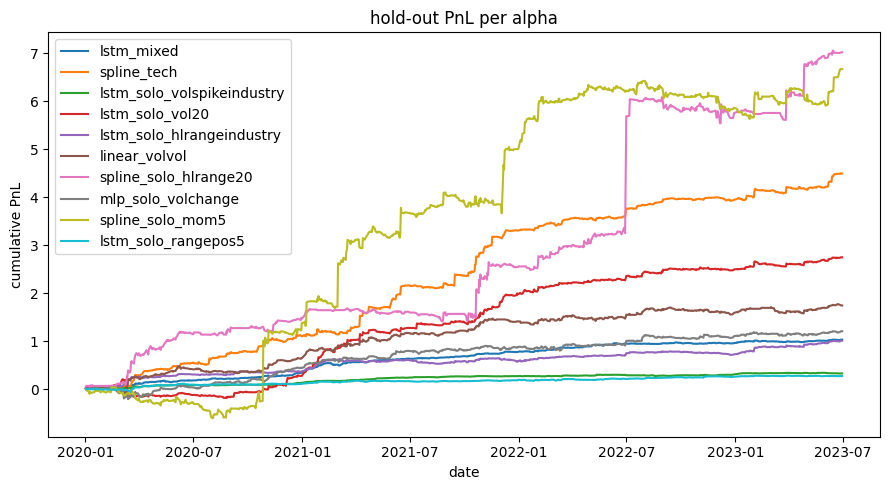

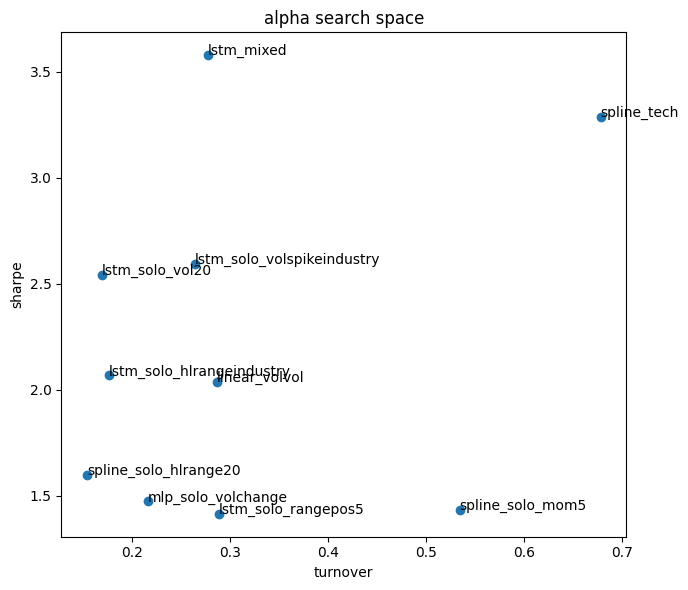

In [7]:
# =====================================================================
# FIXED 4 -- evaluate the alphas   (per alpha, then together)
# =====================================================================
# Per-alpha stats (Sharpe, total PnL, turnover, ...), the
# correlation between alphas, and the combined Sharpe of the best
# un-correlated set -- exactly what the grader does on its hidden
# period.

kpi_table = toolkit.compute_kpis(positions, forward_returns)
print("per-alpha stats:\n", kpi_table.round(4))

print("\nPnL correlation:\n",
      toolkit.pnl_correlation(alphas).round(2))

kept = toolkit.select_uncorrelated(alphas, max_corr=0.5)
print("\nun-alike alphas kept:", kept)
print("combined Sharpe (kept):",
      round(toolkit.combined_sharpe(alphas, kept), 4))

# See the curves while developing (does not affect grading).
toolkit.plot_pnl(alphas, "hold-out PnL per alpha")
toolkit.plot_kpis(kpi_table)

In [8]:
# =====================================================================
# FIXED 5 -- write the submission
# =====================================================================
# For every kept alpha, save two things: the trained model and the
# list of feature names it used.  Submit this folder together with
# your notebook (your feature definitions live in the notebook).
SUBMISSION_DIR = "../output"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

for i in kept:
    torch.save(trained[i], os.path.join(SUBMISSION_DIR, "model_%s.pt" % i))

params = {
    "alphas": kept,
    "feature_sets": {i: feature_sets[i] for i in kept},
}
with open(os.path.join(SUBMISSION_DIR, "params.json"), "w") as handle:
    json.dump(params, handle, indent=2)

print("submission written to", os.path.abspath(SUBMISSION_DIR))

submission written to C:\Users\שקד כהן\Downloads\Applied-Machine-Learning\output
